Authors:
- Iria Janeiro Pazos.
- Laura González Lemos.

In [ ]:
import random
random.seed(1234)

In [2]:
# Download dataset
import tensorflow as tf
import tensorflow_datasets as tfds

raw_train_data, train_info = tfds.load('stl10', split='train', as_supervised=True, with_info=True) # tuple (image, label)
raw_test_data, test_info = tfds.load('stl10', split='test', as_supervised=True, with_info=True) # tuple (image, label)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.2HAFCF_1.0.0/stl10-test.tfrecord*...:   0%|          | 0/…

Generating unlabelled examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.2HAFCF_1.0.0/stl10-unlabelled.tfrecord*...:   0%|        …

Dataset stl10 downloaded and prepared to /root/tensorflow_datasets/stl10/1.0.0. Subsequent calls will reuse this data.


In [14]:
import matplotlib.pyplot as plt

def plot_history(history, model_name="Model"):
    """
    Plots the training and validation accuracy and loss.
    """
    # Extract metrics from the history object [cite: 230]
    acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')
    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
    plt.title(f'{model_name}: Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.ylim(0, 1)  # Set y-axis limits for better visualization

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
    plt.title(f'{model_name}: Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


,image,label
0,,1 (bird)
1,,0 (airplane)
2,,8 (ship)
3,,3 (cat)

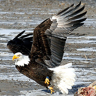
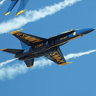
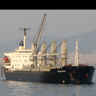
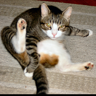

In [3]:
# Check train data
print('Number of classes:', train_info.features["label"].num_classes)
print('Classes names:', train_info.features["label"].names)
print()
print('Features shape:', train_info.features["image"].shape)
print('Features dtype:', train_info.features["image"].dtype)


tfds.as_dataframe(raw_train_data.take(4), train_info)


Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


,image,label
0,,9 (truck)
1,,3 (cat)
2,,3 (cat)
3,,1 (bird)

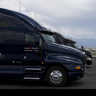
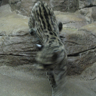
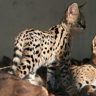
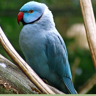

In [4]:
# Check test data
print('Number of classes:', test_info.features["label"].num_classes)
print('Classes names:', test_info.features["label"].names)
print()
print('Features shape:', test_info.features["image"].shape)
print('Features dtype:', test_info.features["image"].dtype)


tfds.as_dataframe(raw_test_data.take(4), test_info)

# Data Preprocessing

The first step in the project is to preprocess the data. We perform the following transformations:
- Image size normalization: We resize all images to a common size to ensure consistency in the input data.
- One hot encoding: We convert categorical labels into a binary format that can be used by machine learning algorithms.

In [5]:
# Preprocessing

def preprocess(image, label, train_info=train_info):
    # Rescale the image (normalize)
    image = tf.cast(image, tf.float32)

    # One-hot encode the labels
    num_classes = train_info.features["label"].num_classes
    label = tf.one_hot(label, depth=num_classes)

    return image, label

prep_train_data = raw_train_data.map(preprocess)
test_data = raw_test_data.map(preprocess)

Secondly, we split the dataset into training and validation sets (80% training, 20% validation). A test split is not needed as the dataset already provides a seperate test set.

In [7]:
# Train-Validation split (80-20)
prep_train_data = prep_train_data.shuffle(1000, reshuffle_each_iteration=False) # Shuffle the dataset before splitting

num_samples = train_info.splits['train'].num_examples
train_size = int(0.8 * num_samples)

train_data = prep_train_data.take(train_size)
val_data = prep_train_data.skip(train_size)

In [8]:
BATCH_SIZE = 32 

# 1. Batch the training data and use prefetch for speed
# We shuffle again here to ensure randomness within the batches
train_data = train_data.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 2. Batch the validation data
val_data = val_data.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 3. Batch the test data (if you plan to evaluate later)
test_data = test_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Baseline Model

probar Aquí tienes excelentes opciones que puedes usar para la Parte 2:

1. La familia ResNet (Redes Residuales)

Modelos: ResNet50 o ResNet101V2.

Por qué usarlo: El propio enunciado menciona las redes "Residual" en la Parte 1. Es casi obligatorio probar un modelo ResNet preentrenado. Son el estándar de la industria y resuelven el problema del desvanecimiento del gradiente.

2. La familia VGG

Modelos: VGG16 o VGG19.

Por qué usarlo: Son arquitecturas clásicas, secuenciales y muy fáciles de entender. Extraen características muy buenas, aunque son modelos pesados y lentos de entrenar en comparación con los modernos. Sirven muy bien como línea base (baseline) para comparar.

3. Inception y Xception

Modelos: InceptionV3 o Xception.

Por qué usarlo: Nuevamente, el profesor menciona explícitamente "Inception or Xception networks" en la Parte 1. Usar sus versiones preentrenadas en la Parte 2 te dará mucho de qué hablar en tu informe al compararlas con tus propias versiones de la Parte 1.

4. EfficientNet

Modelos: EfficientNetB0 a EfficientNetB7 (Te sugiero empezar por B0 o B1).

Por qué usarlo: Son modelos mucho más modernos y eficientes (logran mayor precisión con menos parámetros). Mostrarán que estás al día con arquitecturas más recientes del estado del arte.

5. Redes ligeras (Opcional)

Modelos: MobileNetV2 o MobileNetV3.

Por qué usarlo: Si quieres agregar a tu comparación un modelo diseñado para ser rápido y ligero (por ejemplo, para dispositivos móviles) y contrastar su precisión frente a "pesos pesados" como VGG16.

Consejos importantes para tu práctica:
Tamaño de entrada (Input Shape): Las imágenes de STL-10 son de 96x96. La mayoría de estos modelos preentrenados (entrenados en ImageNet) aceptan imágenes desde 32x32 o 75x75 en adelante, así que 96x96 funcionará perfectamente usando input_shape=(96, 96, 3) e include_top=False.

Estrategias obligatorias: Recuerda que la rúbrica exige que pruebes ambas estrategias con estos modelos:

Feature Extraction: Congelar (freeze) todas las capas base del modelo preentrenado y solo entrenar tu propia capa densa (clasificador) al final.

Fine-tuning: Después del paso anterior, descongelar las últimas capas convolucionales del modelo base y volver a entrenar con una tasa de aprendizaje (learning rate) muy baja para ajustar los pesos específicos al dataset STL-10.

Comparación: El profesor evaluará fuertemente que compares los resultados entre ellos y contra la red CNN personalizada que hiciste en la Parte 1. Por ejemplo, puedes comparar un VGG16 (Feature Extraction) vs VGG16 (Fine-tuning) vs ResNet50 vs Tu propia red.

In [29]:
#La familia ResNet (Redes Residuales)

#Modelos: ResNet50 o ResNet101V2.

def train_model(model, train_data, val_data, model_name="Model", learning_rate=0.001, epochs=25):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), 
        loss='categorical_crossentropy', 
        metrics=['accuracy']
    )

    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=callbacks
    )
    return history

    

## ResNet50

In [10]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

def build_resnet50_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape = input_shape)
    
    x = preprocess_input(inputs)
    
    base_model = ResNet50(
        weights='imagenet',
        include_top = False,
        input_tensor = x
    )

    base_model.trainable = False

    x = base_model.output

    x = layers.GlobalAveragePooling2D()(x)

    # Add Dropout

    x = layers.Dropout(0.3)(x)

    outputs= layers.Dense(num_classes, activation = 'softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model, base_model


In [11]:
img_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

resnet50_model, base_model = build_resnet50_model(img_shape, num_classes)
resnet50_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 96, 96)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 96, 96)    │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 96, 96)    │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 96, 96, 3) │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96, 3) │          0 │ stack[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 102, 102,  │          0 │ add[0][0]         │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 48, 48,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 48, 48,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 48, 48,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 50, 50,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 24, 24,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 24, 24,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 24, 24,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 24, 24,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 24, 24,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 24, 24,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                 

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history_resnet50 = train_model(model=resnet50_model, train_data=train_data, val_data=val_data,model_name="ResNet50_FeatureExtraction", learning_rate=0.001, epochs=25)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 109ms/step - accuracy: 0.5494 - loss: 2.1356 - val_accuracy: 0.8790 - val_loss: 0.4501
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8679 - loss: 0.5032 - val_accuracy: 0.8920 - val_loss: 0.4115
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9001 - loss: 0.3593 - val_accuracy: 0.8770 - val_loss: 0.4861
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9095 - loss: 0.3074 - val_accuracy: 0.8890 - val_loss: 0.4114
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9238 - loss: 0.2308 - val_accuracy: 0.8910 - val_loss: 0.4940
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9349 - loss: 0.2188 - val_accuracy: 0.8910 - val_loss: 0.4859
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9418 - loss: 0.1762 - val_accuracy: 0.8920 - val_loss: 0.4874
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9572 - loss: 0.1320 - val_ac

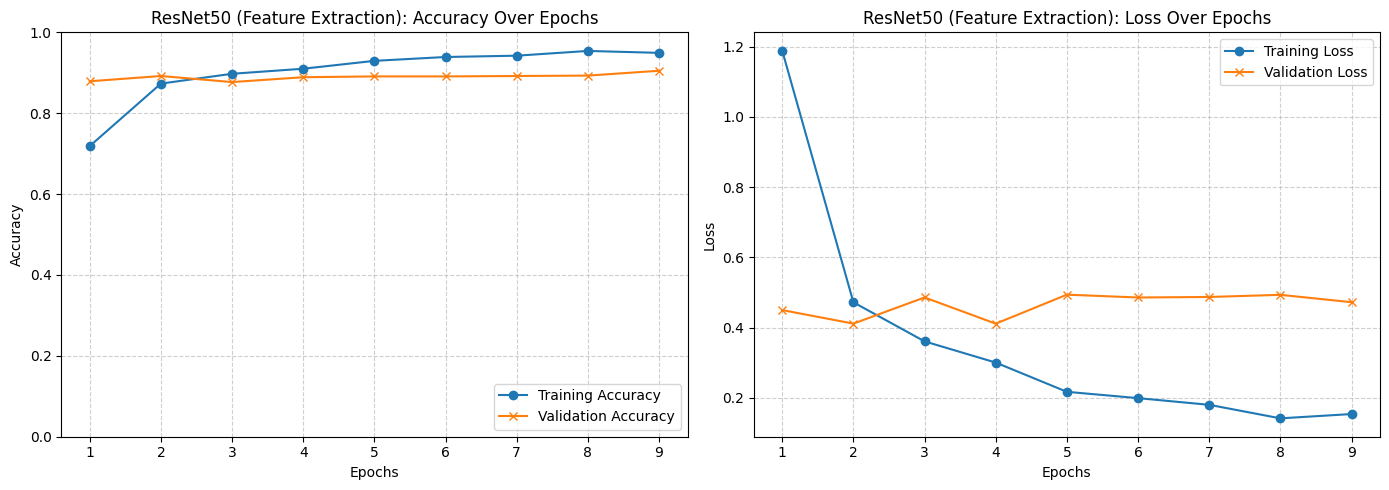

In [15]:
plot_history(history_resnet50, model_name="ResNet50 (Feature Extraction)")

## ResNet101V2


In [16]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet101V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input as preprocess_input_v2
import tensorflow as tf

def build_resnet101v2_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape = input_shape)
    
    x = preprocess_input_v2(inputs)
    
    base_model = ResNet101V2(
        weights='imagenet',
        include_top = False,
        input_shape = input_shape
    )

    base_model.trainable = False

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    # Add Dropout

    x = layers.Dropout(0.3)(x)

    outputs= layers.Dense(num_classes, activation = 'softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model, base_model


In [17]:
img_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

resnet101_model, base_model_101 = build_resnet101v2_model(img_shape, num_classes)
resnet101_model.summary()

171317808/171317808 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet101v2 (Functional)        │ (None, 3, 3, 2048)     │    42,626,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,647,050 (162.69 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 42,626,560 (162.61 MB)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 129ms/step - accuracy: 0.5106 - loss: 2.3957 - val_accuracy: 0.8130 - val_loss: 0.6748
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.8319 - loss: 0.6424 - val_accuracy: 0.8310 - val_loss: 0.6031
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.8674 - loss: 0.4748 - val_accuracy: 0.8380 - val_loss: 0.6055
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.8907 - loss: 0.3976 - val_accuracy: 0.8430 - val_loss: 0.5924
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8992 - loss: 0.3353 - val_accuracy: 0.8400 - val_loss: 0.5992
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9133 - loss: 0.2619 - val_accuracy: 0.8400 - val_loss: 0.6269
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9241 - loss: 0.2503 - val_accuracy: 0.8380 - val_loss: 0.6546
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9219 - loss: 0.2574 - val_ac

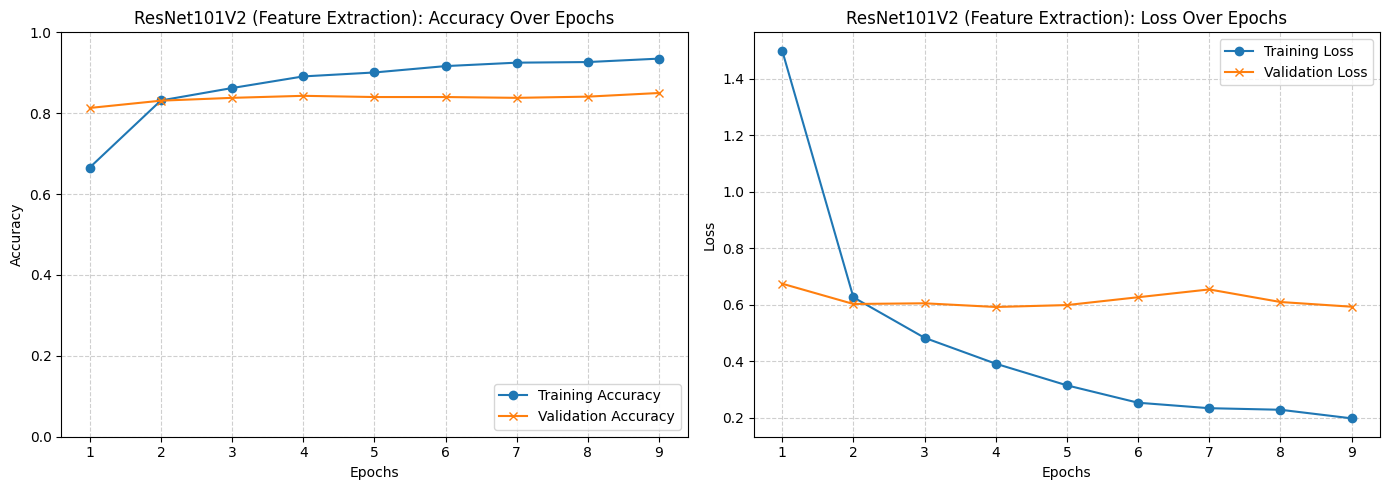

In [ ]:
history_resnet101 = train_model(
    model=resnet101_model, 
    train_data=train_data, 
    val_data=val_data,
    model_name="ResNet101V2_FeatureExtraction", 
    learning_rate=0.001, 
    epochs=25
)

# Y dibujar los resultados
plot_history(history_resnet101, model_name="ResNet101V2 (Feature Extraction)")

## VGG16

In [19]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_input_vgg
import tensorflow as tf

def build_vgg16_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)
    
    x = preprocess_input_vgg(inputs)
    
    base_model = VGG16(
        weights='imagenet', 
        include_top=False,  
        input_shape=input_shape 
    )

    base_model.trainable = False

    x = base_model(x, training=False) 

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model, base_model

In [20]:
img_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

vgg16_model, base_model_vgg = build_vgg16_model(img_shape, num_classes)

vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 96, 96)    │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 96, 96)    │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 96, 96)    │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 96, 96, 3) │          0 │ get_item_3[0][0], │
│                     │                   │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 96, 96, 3) │          0 │ stack_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 3, 3, 512) │ 14,714,688 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │      5,130 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,719,818 (56.15 MB)

 Trainable params: 5,130 (20.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history_vgg16 = train_model(
    model=vgg16_model, 
    train_data=train_data, 
    val_data=val_data,
    model_name="VGG16_FeatureExtraction", 
    learning_rate=0.001, 
    epochs=25
    
)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.2731 - loss: 14.9996 - val_accuracy: 0.7270 - val_loss: 2.3115
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.6831 - loss: 3.7003 - val_accuracy: 0.8130 - val_loss: 1.4049
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.7589 - loss: 2.4950 - val_accuracy: 0.8490 - val_loss: 1.1097
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8024 - loss: 1.6905 - val_accuracy: 0.8570 - val_loss: 1.0183
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8247 - loss: 1.3965 - val_accuracy: 0.8660 - val_loss: 0.9105
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8409 - loss: 1.3086 - val_accuracy: 0.8620 - val_loss: 0.9293
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8435 - loss: 1.0998 - val_accuracy: 0.8630 - val_loss: 0.9466
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8681 - loss: 0.8737 - val_ac

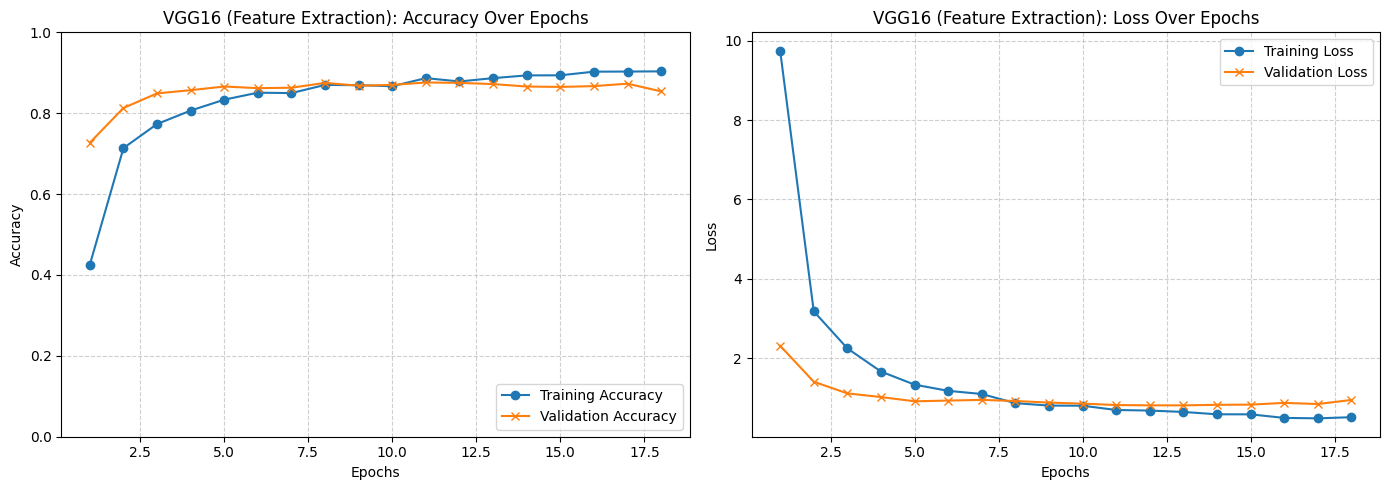

In [22]:
plot_history(history_vgg16, model_name="VGG16 (Feature Extraction)")

## Xception

In [23]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input as preprocess_input_xception

def build_xception_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    x = preprocess_input_xception(inputs)

    base_model = Xception(
        weights='imagenet', 
        include_top=False,  
        input_shape=input_shape 
    )

    base_model.trainable = False

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)

    return model, base_model

In [24]:
img_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

xception_model, base_model_xception = build_xception_model(img_shape, num_classes)

xception_model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 3, 3, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,881,970 (79.66 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 150ms/step - accuracy: 0.6152 - loss: 1.1991 - val_accuracy: 0.8380 - val_loss: 0.4819
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8641 - loss: 0.4388 - val_accuracy: 0.8530 - val_loss: 0.4356
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8841 - loss: 0.3552 - val_accuracy: 0.8600 - val_loss: 0.4279
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9002 - loss: 0.3172 - val_accuracy: 0.8720 - val_loss: 0.4081
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9081 - loss: 0.2765 - val_accuracy: 0.8650 - val_loss: 0.4114
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9235 - loss: 0.2381 - val_accuracy: 0.8780 - val_loss: 0.3988
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9323 - loss: 0.2142 - val_accuracy: 0.8700 - val_loss: 0.4189
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9355 - loss: 0.2024 - val_ac

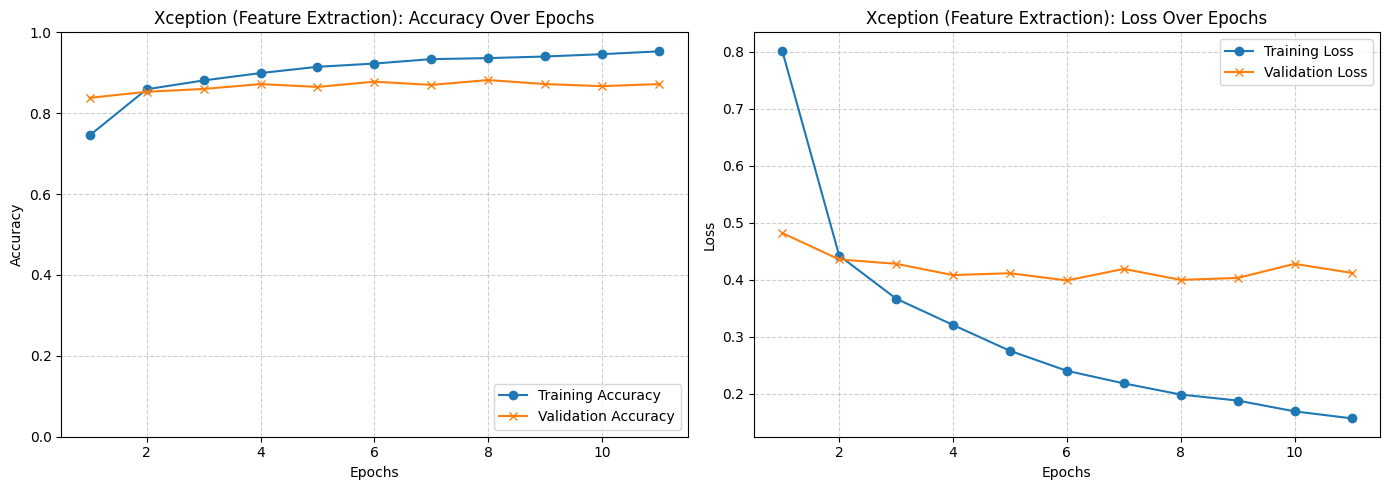

In [ ]:
history_xception = train_model(
    model=xception_model, 
    train_data=train_data, 
    val_data=val_data,
    model_name="Xception_FeatureExtraction", 
    learning_rate=0.001, 
    epochs=25
)

# Y dibujamos la gráfica
plot_history(history_xception, model_name="Xception (Feature Extraction)")

## EfficientNetB0

In [26]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_input_eff

def build_efficientnetb0_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)
    
    x = preprocess_input_eff(inputs)
    
    base_model = EfficientNetB0(
        weights='imagenet', 
        include_top=False,  
        input_shape=input_shape 
    )
    
    base_model.trainable = False 
    
    x = base_model(x, training=False)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    return model, base_model

In [27]:
img_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

efficientnet_model, base_model_eff = build_efficientnetb0_model(img_shape, num_classes)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 156ms/step - accuracy: 0.5606 - loss: 1.4461 - val_accuracy: 0.8990 - val_loss: 0.4686
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8868 - loss: 0.4442 - val_accuracy: 0.9070 - val_loss: 0.3440
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9167 - loss: 0.3082 - val_accuracy: 0.9160 - val_loss: 0.3042
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9244 - loss: 0.2535 - val_accuracy: 0.9160 - val_loss: 0.2869
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9327 - loss: 0.2265 - val_accuracy: 0.9200 - val_loss: 0.2755
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9422 - loss: 0.1941 - val_accuracy: 0.9170 - val_loss: 0.2701
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9582 - loss: 0.1614 - val_accuracy: 0.9180 - val_loss: 0.2706
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9509 - loss: 0.1636 - val_ac

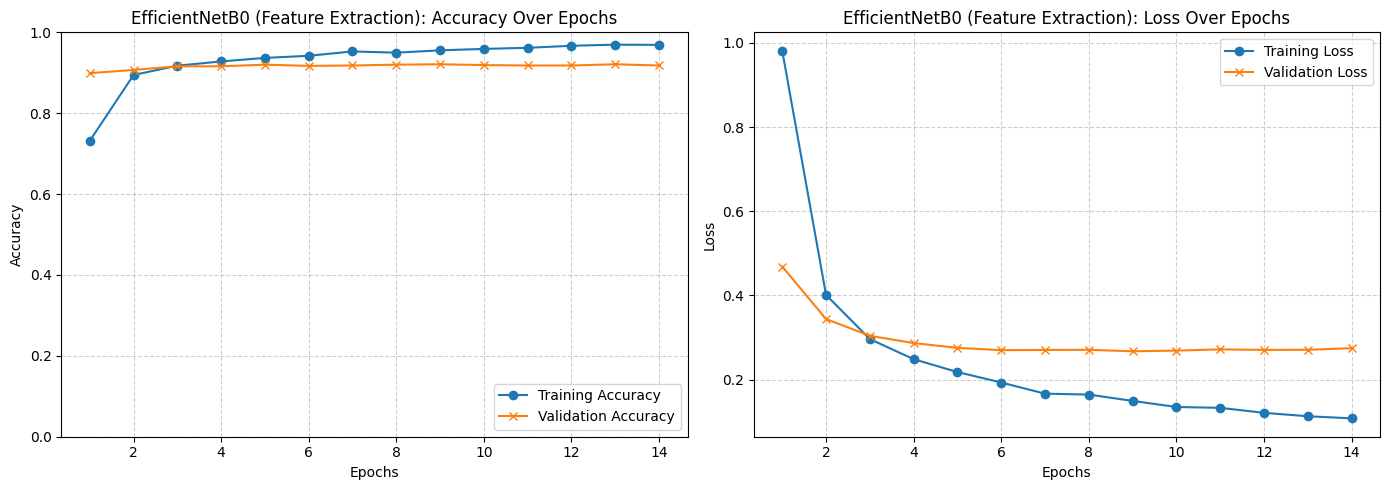

In [ ]:
history_eff_fe = train_model(
    model=efficientnet_model, 
    train_data=train_data, 
    val_data=val_data,
    model_name="EfficientNetB0_FeatureExtraction", 
    learning_rate=0.001, 
    epochs=25
)

# Dibujar la gráfica
plot_history(history_eff_fe, model_name="EfficientNetB0 (Feature Extraction)")

# Fine-Tuning

In [30]:
def fine_tuning(model, base_model, train_data, val_data, unfreeze_last_n_layers=30, lr=1e-5, epochs=15):
    base_model.trainable = True
    
    for layer in base_model.layers[:-unfreeze_last_n_layers]:
        layer.trainable = False
        
    # print(f"Capas totales en el modelo base: {len(base_model.layers)}")
    # print(f"Capas entrenables ahora: {unfreeze_last_n_layers}")
        
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
    
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=callbacks
    )
    
    return history

## EfficientNetB0

--- Fine-Tuning EfficientNetB0 ---
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 109ms/step - accuracy: 0.8860 - loss: 0.3749 - val_accuracy: 0.9020 - val_loss: 0.3247
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8991 - loss: 0.3152 - val_accuracy: 0.8870 - val_loss: 0.3551
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9052 - loss: 0.2943 - val_accuracy: 0.8860 - val_loss: 0.3574
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9011 - loss: 0.2947 - val_accuracy: 0.8870 - val_loss: 0.3520
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9154 - loss: 0.2629 - val_accuracy: 0.8860 - val_loss: 0.3442
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9259 - loss: 0.2453 - val_accuracy: 0.8910 - val_loss: 0.3359


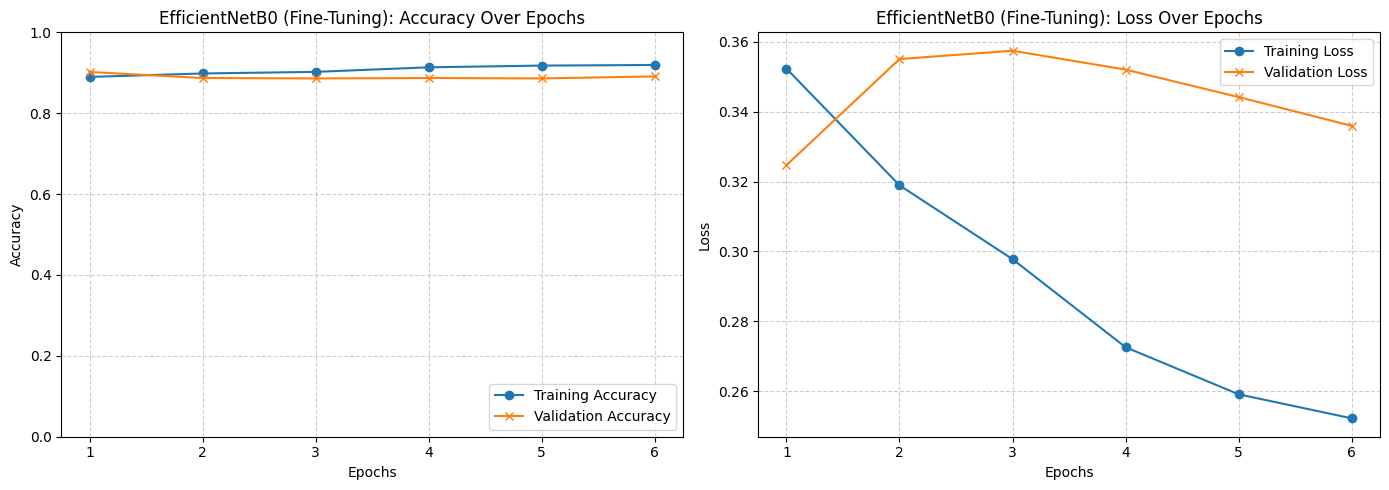

In [31]:
print("--- Fine-Tuning EfficientNetB0 ---")
history_eff_ft = fine_tuning(
    model=efficientnet_model, 
    base_model=base_model_eff, 
    train_data=train_data, 
    val_data=val_data, 
    unfreeze_last_n_layers=20, 
    lr=1e-5
)
plot_history(history_eff_ft, model_name="EfficientNetB0 (Fine-Tuning)")

## ResNet50

--- Fine-Tuning ResNet50 ---
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 95ms/step - accuracy: 0.8630 - loss: 0.4052 - val_accuracy: 0.8780 - val_loss: 0.3800
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9170 - loss: 0.2446 - val_accuracy: 0.8770 - val_loss: 0.3715
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9500 - loss: 0.1687 - val_accuracy: 0.8770 - val_loss: 0.3634
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9602 - loss: 0.1322 - val_accuracy: 0.8800 - val_loss: 0.3544
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9745 - loss: 0.0961 - val_accuracy: 0.8860 - val_loss: 0.3486
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9838 - loss: 0.0749 - val_accuracy: 0.8880 - val_loss: 0.3480
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9868 - loss: 0.0643 - val_accuracy: 0.8920 - val_loss: 0.3460
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.

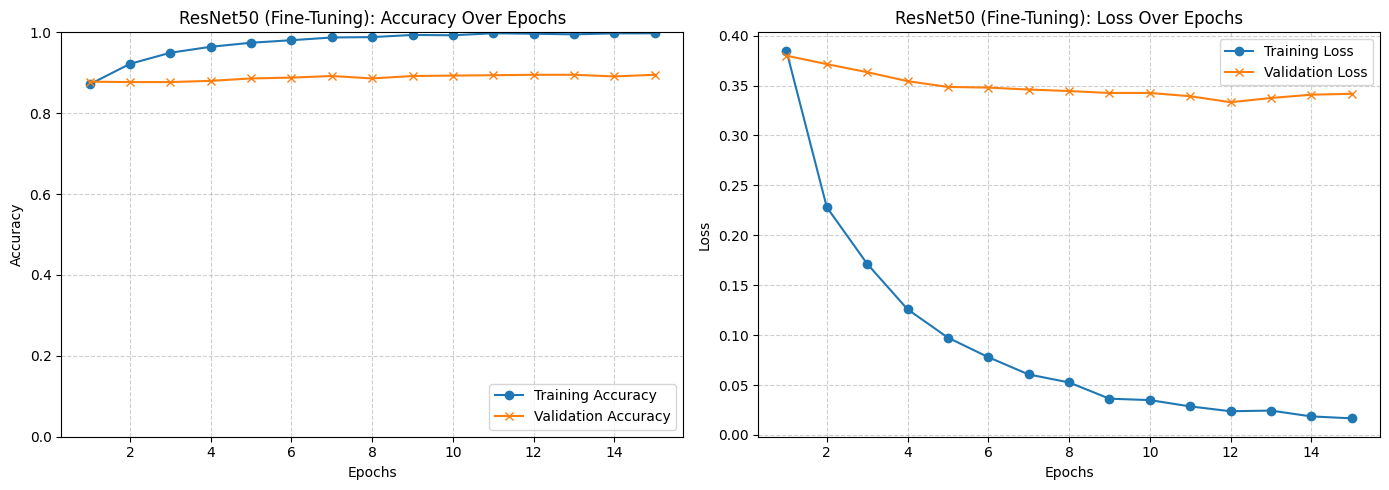

In [32]:
print("--- Fine-Tuning ResNet50 ---")
history_resnet50_ft = fine_tuning(
    model=resnet50_model, 
    base_model=base_model, 
    train_data=train_data, 
    val_data=val_data, 
    unfreeze_last_n_layers=30, 
    lr=1e-5
)
plot_history(history_resnet50_ft, model_name="ResNet50 (Fine-Tuning)")

## Xception

--- Fine-Tuning Xception ---
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 110ms/step - accuracy: 0.6477 - loss: 1.4663 - val_accuracy: 0.8290 - val_loss: 0.5143
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.7829 - loss: 1.0475 - val_accuracy: 0.8410 - val_loss: 0.5048
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8318 - loss: 0.7580 - val_accuracy: 0.8450 - val_loss: 0.5169
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.8465 - loss: 0.6048 - val_accuracy: 0.8540 - val_loss: 0.5479
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8784 - loss: 0.4939 - val_accuracy: 0.8620 - val_loss: 0.5180
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8893 - loss: 0.4134 - val_accuracy: 0.8660 - val_loss: 0.4769
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.8961 - loss: 0.3646 - val_accuracy: 0.8680 - val_loss: 0.4647
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0

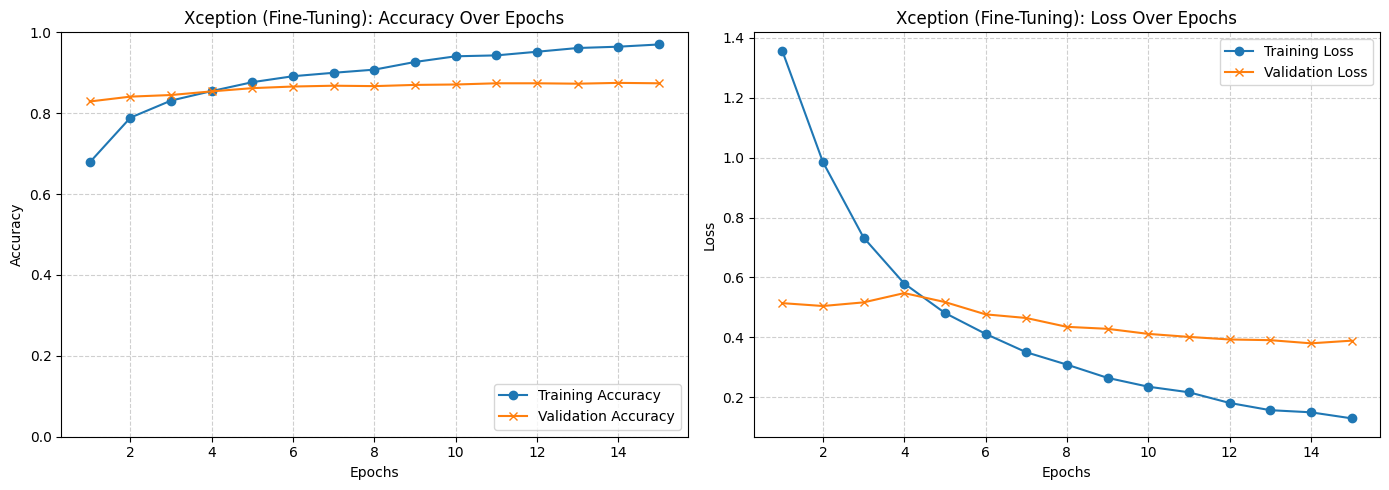

In [33]:
print("--- Fine-Tuning Xception ---")
history_xception_ft = fine_tuning(
    model=xception_model, 
    base_model=base_model_xception, 
    train_data=train_data, 
    val_data=val_data, 
    unfreeze_last_n_layers=40, 
    lr=1e-5
)
plot_history(history_xception_ft, model_name="Xception (Fine-Tuning)")

## VGG16

--- Fine-Tuning VGG16 ---
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.8904 - loss: 0.5419 - val_accuracy: 0.8730 - val_loss: 0.5992
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.9174 - loss: 0.2925 - val_accuracy: 0.8800 - val_loss: 0.5657
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.9477 - loss: 0.1701 - val_accuracy: 0.8750 - val_loss: 0.5550
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.9592 - loss: 0.1297 - val_accuracy: 0.8770 - val_loss: 0.5519
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.9671 - loss: 0.1163 - val_accuracy: 0.8790 - val_loss: 0.5471
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.9768 - loss: 0.0738 - val_accuracy: 0.8850 - val_loss: 0.5410
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.9764 - loss: 0.0794 - val_accuracy: 0.8850 - val_loss: 0.5400
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.978

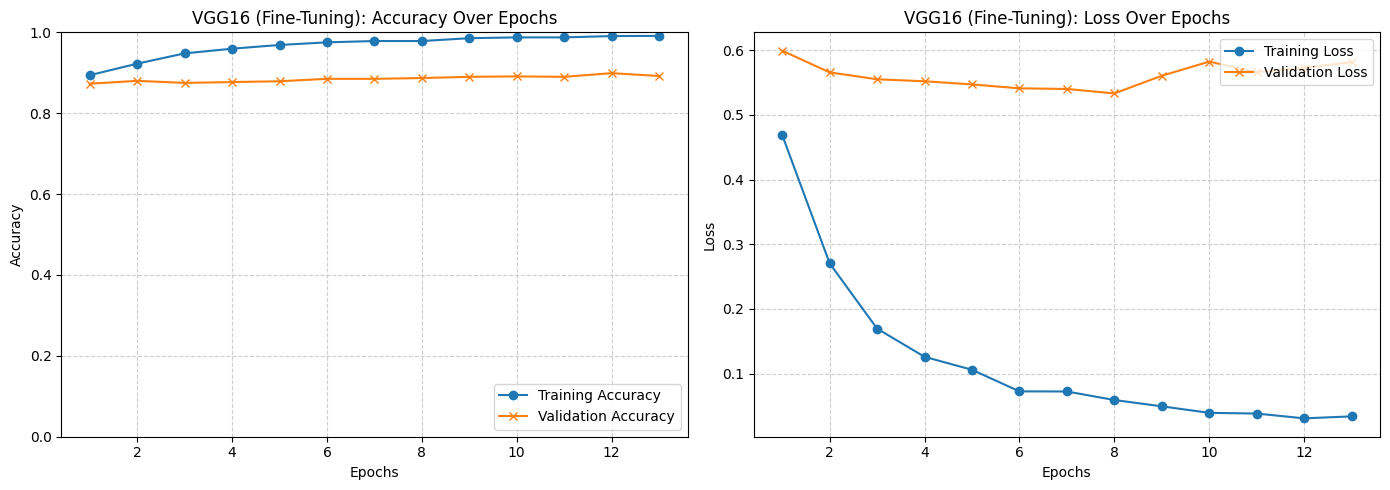

In [34]:
print("--- Fine-Tuning VGG16 ---")
history_vgg16_ft = fine_tuning(
    model=vgg16_model, 
    base_model=base_model_vgg, 
    train_data=train_data, 
    val_data=val_data, 
    unfreeze_last_n_layers=4,
    lr=1e-5
)
plot_history(history_vgg16_ft, model_name="VGG16 (Fine-Tuning)")

## ResNet101V2

--- Fine-Tuning ResNet101V2 ---
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 139ms/step - accuracy: 0.6723 - loss: 0.9890 - val_accuracy: 0.7880 - val_loss: 0.6329
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.7820 - loss: 0.6728 - val_accuracy: 0.7650 - val_loss: 0.6447
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.8519 - loss: 0.4649 - val_accuracy: 0.7820 - val_loss: 0.6156
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.8941 - loss: 0.3464 - val_accuracy: 0.7900 - val_loss: 0.5912
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.9305 - loss: 0.2750 - val_accuracy: 0.8050 - val_loss: 0.5630
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.9519 - loss: 0.2136 - val_accuracy: 0.8130 - val_loss: 0.5415
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.9587 - loss: 0.1770 - val_accuracy: 0.8160 - val_loss: 0.5316
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accurac

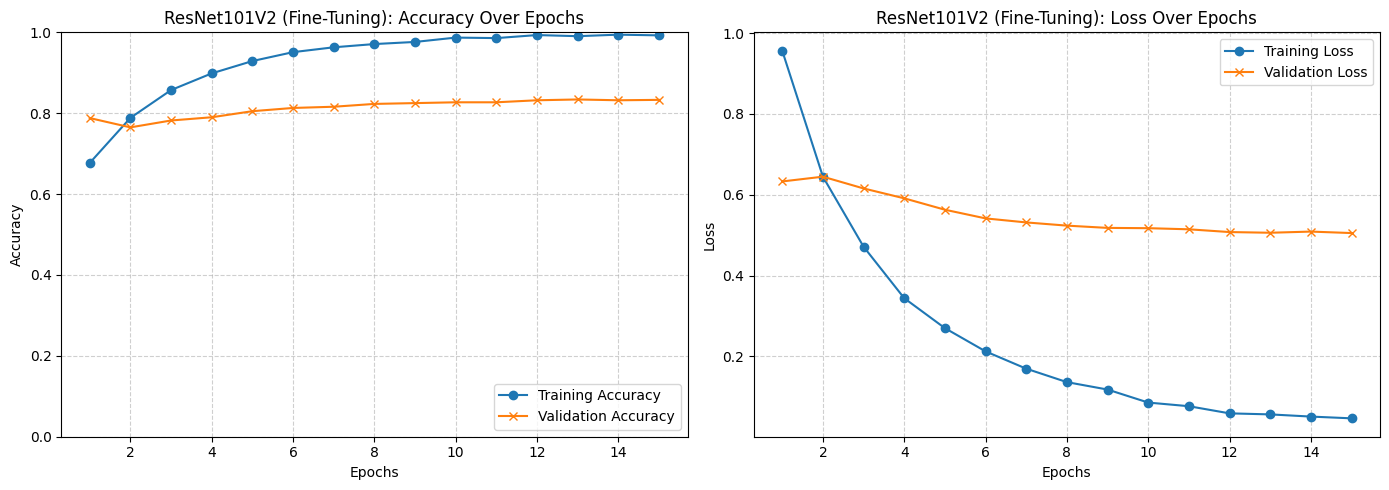

In [35]:
print("--- Fine-Tuning ResNet101V2 ---")
history_resnet101_ft = fine_tuning(
    model=resnet101_model, 
    base_model=base_model_101, 
    train_data=train_data, 
    val_data=val_data, 
    unfreeze_last_n_layers=40, 
    lr=1e-5
)
plot_history(history_resnet101_ft, model_name="ResNet101V2 (Fine-Tuning)")